In [1]:
from google.colab import files
uploaded = files.upload()

Saving bengaluru_house_prices.csv to bengaluru_house_prices.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [3]:
df = pd.read_csv("bengaluru_house_prices.csv")

df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [4]:
df.isnull().sum()

,0
area_type,0
availability,0
location,1
size,16
society,5502
total_sqft,0
bath,73
balcony,609
price,0


In [5]:
df = df[['total_sqft','size','location','price']]

In [6]:
df = df.dropna()

In [7]:
df['bedrooms'] = df['size'].str.extract('(\d+)')
df['bedrooms'] = df['bedrooms'].astype(int)

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_12125/908951682.py:1: SyntaxWarning: invalid escape sequence '\d'
  df['bedrooms'] = df['size'].str.extract('(\d+)')


In [8]:
df.head()

,total_sqft,size,location,price,bedrooms
0,1056,2 BHK,Electronic City Phase II,39.07,2
1,2600,4 Bedroom,Chikka Tirupathi,120.00,4
2,1440,3 BHK,Uttarahalli,62.00,3
3,1521,3 BHK,Lingadheeranahalli,95.00,3
4,1200,2 BHK,Kothanur,51.00,2


In [9]:
df = df[df['total_sqft'].str.contains('-') == False]

In [10]:
df['total_sqft'] = pd.to_numeric(df['total_sqft'], errors='coerce')

In [11]:
df = df.dropna()

In [12]:
le = LabelEncoder()

df['location'] = le.fit_transform(df['location'])

In [13]:
X = df[['total_sqft','bedrooms','location']]
y = df['price']

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [15]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [16]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[126.54995664  98.21678117  77.76541089  60.94107082  68.53578336
  71.22523075  91.91729952 144.38544812 242.05290337  68.87404808]


In [17]:
mae = mean_absolute_error(y_test, y_pred)

print("MAE =", mae)

MAE = 45.37477138938491


In [18]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("RMSE =", rmse)

RMSE = 107.23743581665606


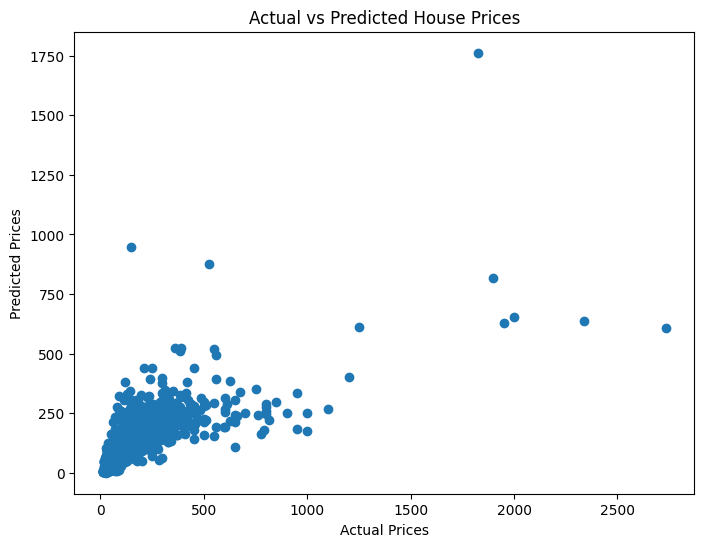

In [19]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted House Prices")

plt.show()

In [20]:
comparison = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_pred
})

comparison.head(20)

,Actual Price,Predicted Price
0,126.00,126.549957
1,70.00,98.216781
2,55.00,77.765411
3,28.88,60.941071
4,77.00,68.535783
5,46.00,71.225231
6,65.00,91.917300
7,122.00,144.385448
8,140.00,242.052903
9,60.00,68.874048
